# Group 2 UX exam

In [77]:
# Import libraries
from scipy import stats
from matplotlib import pyplot as plt
import re
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
import pingouin
import tidyverse as tv
from scipy.stats import norm

In [78]:
# Import the excel file
df = pd.read_excel('CompletionAndCollision.xlsx')

for col in df.columns:
    df[col] = df[col].replace(',', '.', regex=True)
    df[col] = df[col].astype('float')


In [79]:
# Collect the time data into a seperate data frame
dfTime = df[['Time 0 obstacles', 'Time 7 obstacles', 'Time 14 obstacles', 'Time 21 obstacles']]

<AxesSubplot:>

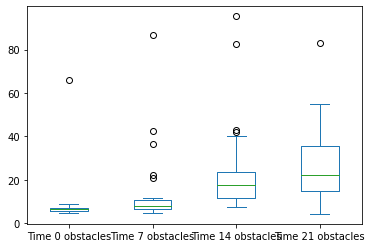

In [80]:
# Visualize the data in boxplots
dfTime.plot.box()

The data contains extreme outliers upon visual analysis

Statistics=0.28, p=0.00000000071090866527


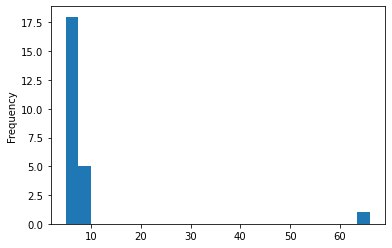

In [81]:
# Time 0 obstacles
dfTime['Time 0 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTime['Time 0 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

Statistics=0.54, p=0.00000013353229633140


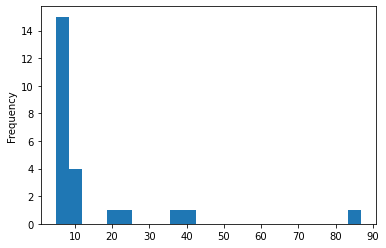

In [82]:
# Time 7 obstacles
dfTime['Time 7 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTime['Time 7 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

Statistics=0.69, p=0.00000652861672278959


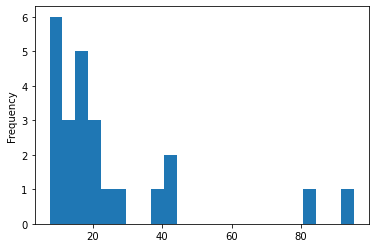

In [83]:
# Time 14 obstacles
dfTime['Time 14 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTime['Time 14 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

Statistics=0.87, p=0.00430775946006178856


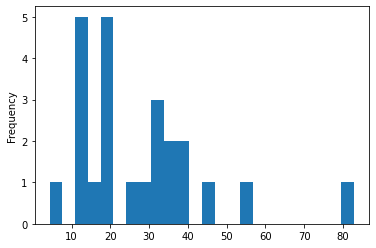

In [84]:
# Time 21 obstacles
dfTime['Time 21 obstacles'].plot.hist(bins=24)
stat, p, = stats.shapiro(dfTime['Time 21 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

# Remove the outliers

In [85]:
# Remove outliers
outlier_indices = set()

for col in dfTime.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].index
    outlier_indices.update(outliers)

# Remove all participants who are outliers in any condition
dfTimeNoOutliers = dfTime.drop(index=outlier_indices)

dfTimeNoOutliers.describe()

,Time 0 obstacles,Time 7 obstacles,Time 14 obstacles,Time 21 obstacles
count,16.000000,16.000000,16.000000,16.000000
mean,6.550000,7.456250,14.462500,21.131250
std,1.100303,1.828285,4.534148,10.050719
min,4.900000,5.000000,7.600000,4.400000
25%,5.750000,6.200000,10.650000,13.725000
50%,6.350000,7.300000,14.850000,19.200000
75%,7.200000,8.175000,17.925000,29.525000
max,8.900000,11.700000,22.700000,37.800000


<AxesSubplot:>

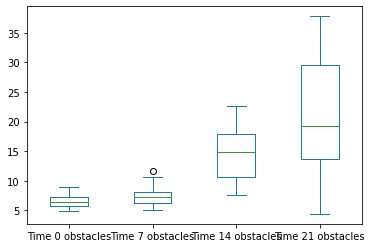

In [86]:
# Visualize the data in boxplots
dfTimeNoOutliers.plot.box()

Statistics=0.97, p=0.84563821554183959961


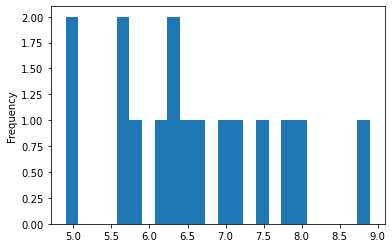

In [87]:
# Time 0 obstacles
dfTimeNoOutliers['Time 0 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTimeNoOutliers['Time 0 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

Statistics=0.93, p=0.25212100148200988770


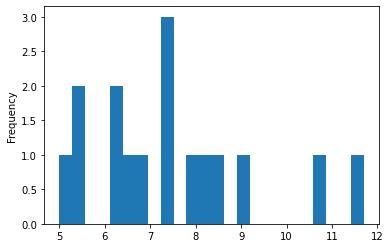

In [88]:
# Time 7 obstacles
dfTimeNoOutliers['Time 7 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTimeNoOutliers['Time 7 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

Statistics=0.94, p=0.40401440858840942383


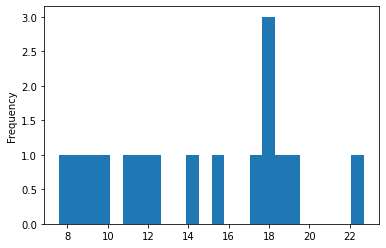

In [89]:
# Time 14 obstacles
dfTimeNoOutliers['Time 14 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTimeNoOutliers['Time 14 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

Statistics=0.92, p=0.18575084209442138672


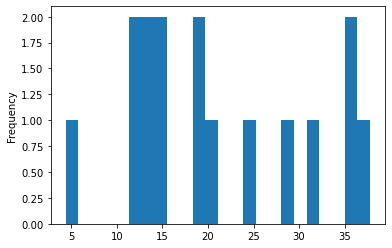

In [90]:
# Time 21 obstacles
dfTimeNoOutliers['Time 21 obstacles'].plot.hist(bins=24)

stat, p, = stats.shapiro(dfTimeNoOutliers['Time 21 obstacles'])
print('Statistics=%.2f, p=%.20f' % (stat, p))

In [91]:
for col in dfTimeNoOutliers.columns:
    data = dfTimeNoOutliers[col].dropna()
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    se = std / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"{col}:")
    print(f"  Mean = {mean:.2f}")
    print(f"  SD = {std:.2f}")
    print(f"  95% CI = ({ci[0]:.2f}, {ci[1]:.2f})\n")

Time 0 obstacles:
  Mean = 6.55
  SD = 1.10
  95% CI = (5.96, 7.14)

Time 7 obstacles:
  Mean = 7.46
  SD = 1.83
  95% CI = (6.48, 8.43)

Time 14 obstacles:
  Mean = 14.46
  SD = 4.53
  95% CI = (12.05, 16.88)

Time 21 obstacles:
  Mean = 21.13
  SD = 10.05
  95% CI = (15.78, 26.49)



In [92]:
# Her valde
pingouin.sphericity(df_long, dv='time', within='obstacles', subject='subj')

TypeError: cov() got an unexpected keyword argument 'numeric_only'